In [2]:
%matplotlib inline

import os
import pandas as pd
import numpy as np
from scipy.io import mmread
import scipy.sparse as sp
import matplotlib.pyplot as plt
from IPython.display import Image
import scanpy as sc
from cnmf import cNMF, Preprocess
import os
from pathlib import Path
import multiprocessing


os.environ["OMP_NUM_THREADS"] = "30"
os.environ["MKL_NUM_THREADS"] = "30"
os.environ["OPENBLAS_NUM_THREADS"] = "30"
os.environ["NUMEXPR_NUM_THREADS"] = "30"
os.environ["VECLIB_MAXIMUM_THREADS"] = "30"
!echo "OMP_NUM_THREADS is set to $OMP_NUM_THREADS"

OMP_NUM_THREADS is set to 30


In [3]:
combined_adata = sc.read_h5ad('/staging//leuven/stg_00079/projects/Magda/analysis/Narwhal/100.Process/01.ExN/12.PFC_noRef_bigger/v2_combined_PFC_L23_rawCounts_h5ad_20251106_raw_cleaned.h5ad')


In [ ]:
combined_adata

In [7]:
combined_adata.layers['counts'] = combined_adata.X.copy()
sc.pp.normalize_total(combined_adata, target_sum=1e4)
sc.pp.log1p(combined_adata)
sc.pp.highly_variable_genes(combined_adata, n_top_genes=8000, batch_key = 'dataset',  subset=True)

In [5]:
combined_adata.X = combined_adata.layers['counts'].copy()
combined_adata.obs_names_make_unique()

/data/leuven/332/vsc33224/miniconda3/envs/py38_07SEP2022/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/data/leuven/332/vsc33224/miniconda3/envs/py38_07SEP2022/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


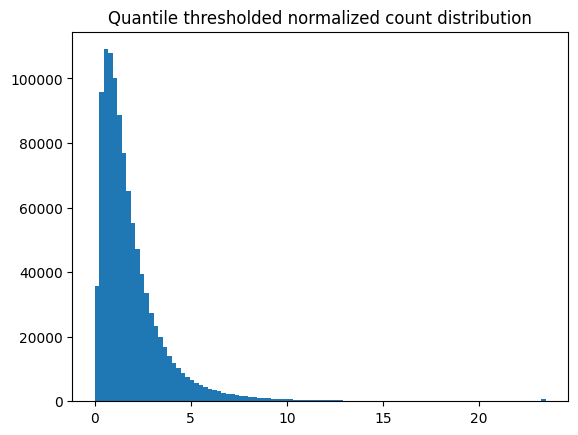

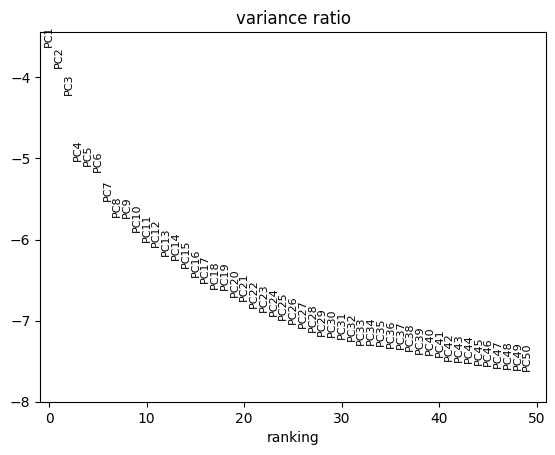

2025-11-10 23:32:24,359 - harmonypy - INFO - Iteration 1 of 20
2025-11-10 23:37:16,799 - harmonypy - INFO - Iteration 2 of 20
2025-11-10 23:41:58,762 - harmonypy - INFO - Iteration 3 of 20
2025-11-10 23:46:36,403 - harmonypy - INFO - Iteration 4 of 20
2025-11-10 23:51:16,832 - harmonypy - INFO - Iteration 5 of 20
2025-11-10 23:55:16,273 - harmonypy - INFO - Iteration 6 of 20
2025-11-10 23:59:29,311 - harmonypy - INFO - Iteration 7 of 20
2025-11-11 00:03:42,159 - harmonypy - INFO - Iteration 8 of 20
2025-11-11 00:07:29,584 - harmonypy - INFO - Iteration 9 of 20
2025-11-11 00:11:29,298 - harmonypy - INFO - Iteration 10 of 20
2025-11-11 00:15:04,092 - harmonypy - INFO - Iteration 11 of 20
2025-11-11 00:18:58,439 - harmonypy - INFO - Iteration 12 of 20
2025-11-11 00:22:30,979 - harmonypy - INFO - Converged after 12 iterations


Only considering the two last: ['.Varnorm', '.h5ad'].
Only considering the two last: ['.Varnorm', '.h5ad'].


In [8]:
p = Preprocess(random_seed=10)
(adata_c, adata_tp10k, hvgs) = p.preprocess_for_cnmf(combined_adata, harmony_vars='dataset', n_top_rna_genes = 4000,
                                                     max_scaled_thresh = None, quantile_thresh = .9999, makeplots=True,
                                                    save_output_base='./cNMF_L23_7NOV_RANGE_cores3_8000/batchcorrect')



In [ ]:
## huge dataset and takes very long time to run
## run 100 iterations, each k value separately

account    = "lp_big_wice_cpu"
partition  = "dedicated_big_bigmem"
cluster    = "wice"
numworkers = 1
cores_per_worker = 20
memory_per_worker = "100G"
time_limit = "100:00:00"
base_dir   = "/staging/leuven/stg_00079/projects/Magda/analysis/Narwhal/200.Modular/01.ExN/0111.Correct"
env_prefix = "/data/leuven/332/vsc33224/miniconda3/envs/py38_07SEP2022"

Path("logs").mkdir(exist_ok=True)

for k in range(15, 25):

    name = f"cNMF_L23_{k}"
    print(f"\n===== Running {name} =====")

    # -----------------------
    # PREPARE STEP
    # -----------------------
    prepare_cmd = (
        f"cnmf prepare "
        f"--output-dir {name} "
        f"--name {name} "
        f"-c ./{name}/batchcorrect.Corrected.HVG.Varnorm.h5ad "
        f"--tpm ./{name}/batchcorrect.TP10K.h5ad "
        f"--genes-file ./{name}/batchcorrect.Corrected.HVGs.txt "
        f"-k {k} "
        f"--n-iter 100 "
        f"--total-workers 1 "
        f"--seed 14 "
        f"--numgenes 4000 "
        f"--beta-loss frobenius"
    )

    print("Prepare command:", prepare_cmd)
    !{prepare_cmd}

    # -----------------------
    # FACTORIZE STEP
    # -----------------------
    sbatch_cmd = (
        f"sbatch "
        f"-A {account} "
        f"--partition={partition} "
        f"--cluster={cluster} "
        f"-J {name} "
        f"-o logs/{name}_%A_%a.out "
        f"-e logs/{name}_%A_%a.err "
        f"--mem={memory_per_worker} "
        f"--time={time_limit} "
        f"-c {cores_per_worker} "
        f"--array=1-{numworkers} "
        f"--chdir={base_dir} "
        f"--wrap='"
        f"source {env_prefix.replace('/envs/py38_07SEP2022','')}/etc/profile.d/conda.sh && "
        f"conda activate {env_prefix} && "
        f"export OMP_NUM_THREADS={cores_per_worker} && "
        f"{env_prefix}/bin/python "
        f"./cnmf.py factorize "
        f"--output-dir {name} "
        f"--name {name} "
        f"--worker-index $SLURM_ARRAY_TASK_ID"
        f"'"
    )

    print("Submitting factorize job...")
    !{sbatch_cmd}


In [1]:
# !!!! manually renamed/merged files into cNMF_joint2 as the next steps expect outputs to be in the same folder
cnmf_obj_corrected = cNMF(output_dir='./cNMF_joint2/', name='cNMF_joint2')


In [ ]:
cmd = 'cnmf prepare --output-dir cNMF_joint2 --name cNMF_joint2 -c ./cNMF_joint2/batchcorrect.Corrected.HVG.Varnorm.h5ad --tpm ./cNMF_joint2//batchcorrect.TP10K.h5ad --genes-file ./cNMF_joint2/batchcorrect.Corrected.HVGs.txt -k 15 16 17 18 19 20 21 22 23 24 --n-iter 100 --total-workers 1 --seed 14 --numgenes 4000 --beta-loss frobenius'
print('Command line - prepare step:    %s' % cmd)
!{cmd}

In [ ]:

num_workers = multiprocessing.cpu_count()
print(f"Number of available CPU cores: {num_workers}")

In [ ]:
cnmf_obj_corrected.combine(skip_missing_files=True)


In [ ]:
cnmf_obj_corrected.k_selection_plot()


In [ ]:
cnmf_obj_corrected.consensus(k=21, density_threshold=0.2, show_clustering=True, close_clustergram_fig=False)

/data/leuven/332/vsc33224/miniconda3/envs/py38_07SEP2022/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


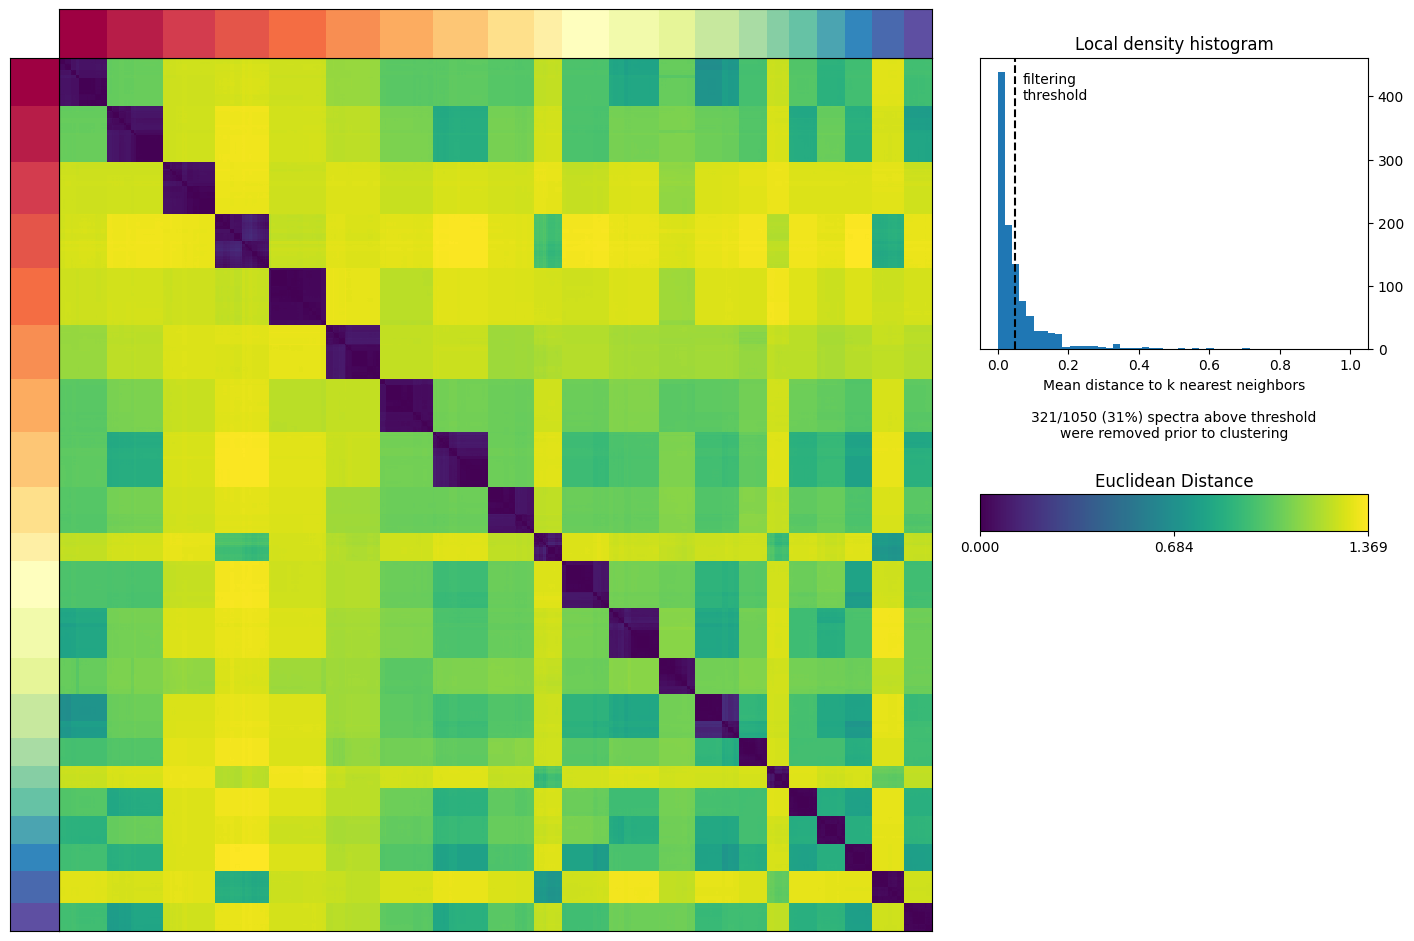

In [5]:
cnmf_obj_corrected.consensus(k=21, density_threshold=0.05, show_clustering=True, close_clustergram_fig=False)

In [5]:
(usage_bc, spectra_scores_bc, spectra_tpm_bc, top_genes_bc) = cnmf_obj_corrected.load_results(K=21, density_threshold=0.05)
usage_bc.head()

,1,2,3,4,5,6,7,8,9,10,...,12,13,14,15,16,17,18,19,20,21
AAACGAAGTAGAGGAA-1-0,0.040241,0.109807,0.062256,0.335897,0.000000,0.000000,0.000000,0.000000,0.077363,0.000000,...,0.000000,0.129375,0.000000,0.000000,0.00000,0.105404,0.131095,0.0,0.000000,0.000000
AAACGAATCTAAGAAG-1-0,0.246229,0.490492,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.021269,0.000000,...,0.121194,0.060544,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.045617,0.014655
AAACGCTCATCTAACG-1-0,0.000000,0.000000,0.050781,0.000000,0.000000,0.053855,0.000000,0.000000,0.105006,0.329547,...,0.000000,0.061702,0.171468,0.125057,0.00000,0.000000,0.059959,0.0,0.042624,0.000000
AAACGCTGTGCATCTA-1-0,0.000000,0.412522,0.026520,0.098671,0.042550,0.000000,0.078266,0.024155,0.000000,0.000000,...,0.022830,0.076193,0.000000,0.008676,0.02072,0.004196,0.000000,0.0,0.000000,0.031290
AAACGCTTCGGTTCAA-1-0,0.084749,0.299352,0.025185,0.123091,0.076688,0.000000,0.000000,0.005240,0.025800,0.000000,...,0.000000,0.194979,0.000000,0.000000,0.00000,0.010590,0.001691,0.0,0.000000,0.000000


In [ ]:
usage_bc.to_csv('./cNMF_usages_by_cell_NORM.csv')

In [7]:
usage_norm_forplot = usage_bc.unstack().reset_index()


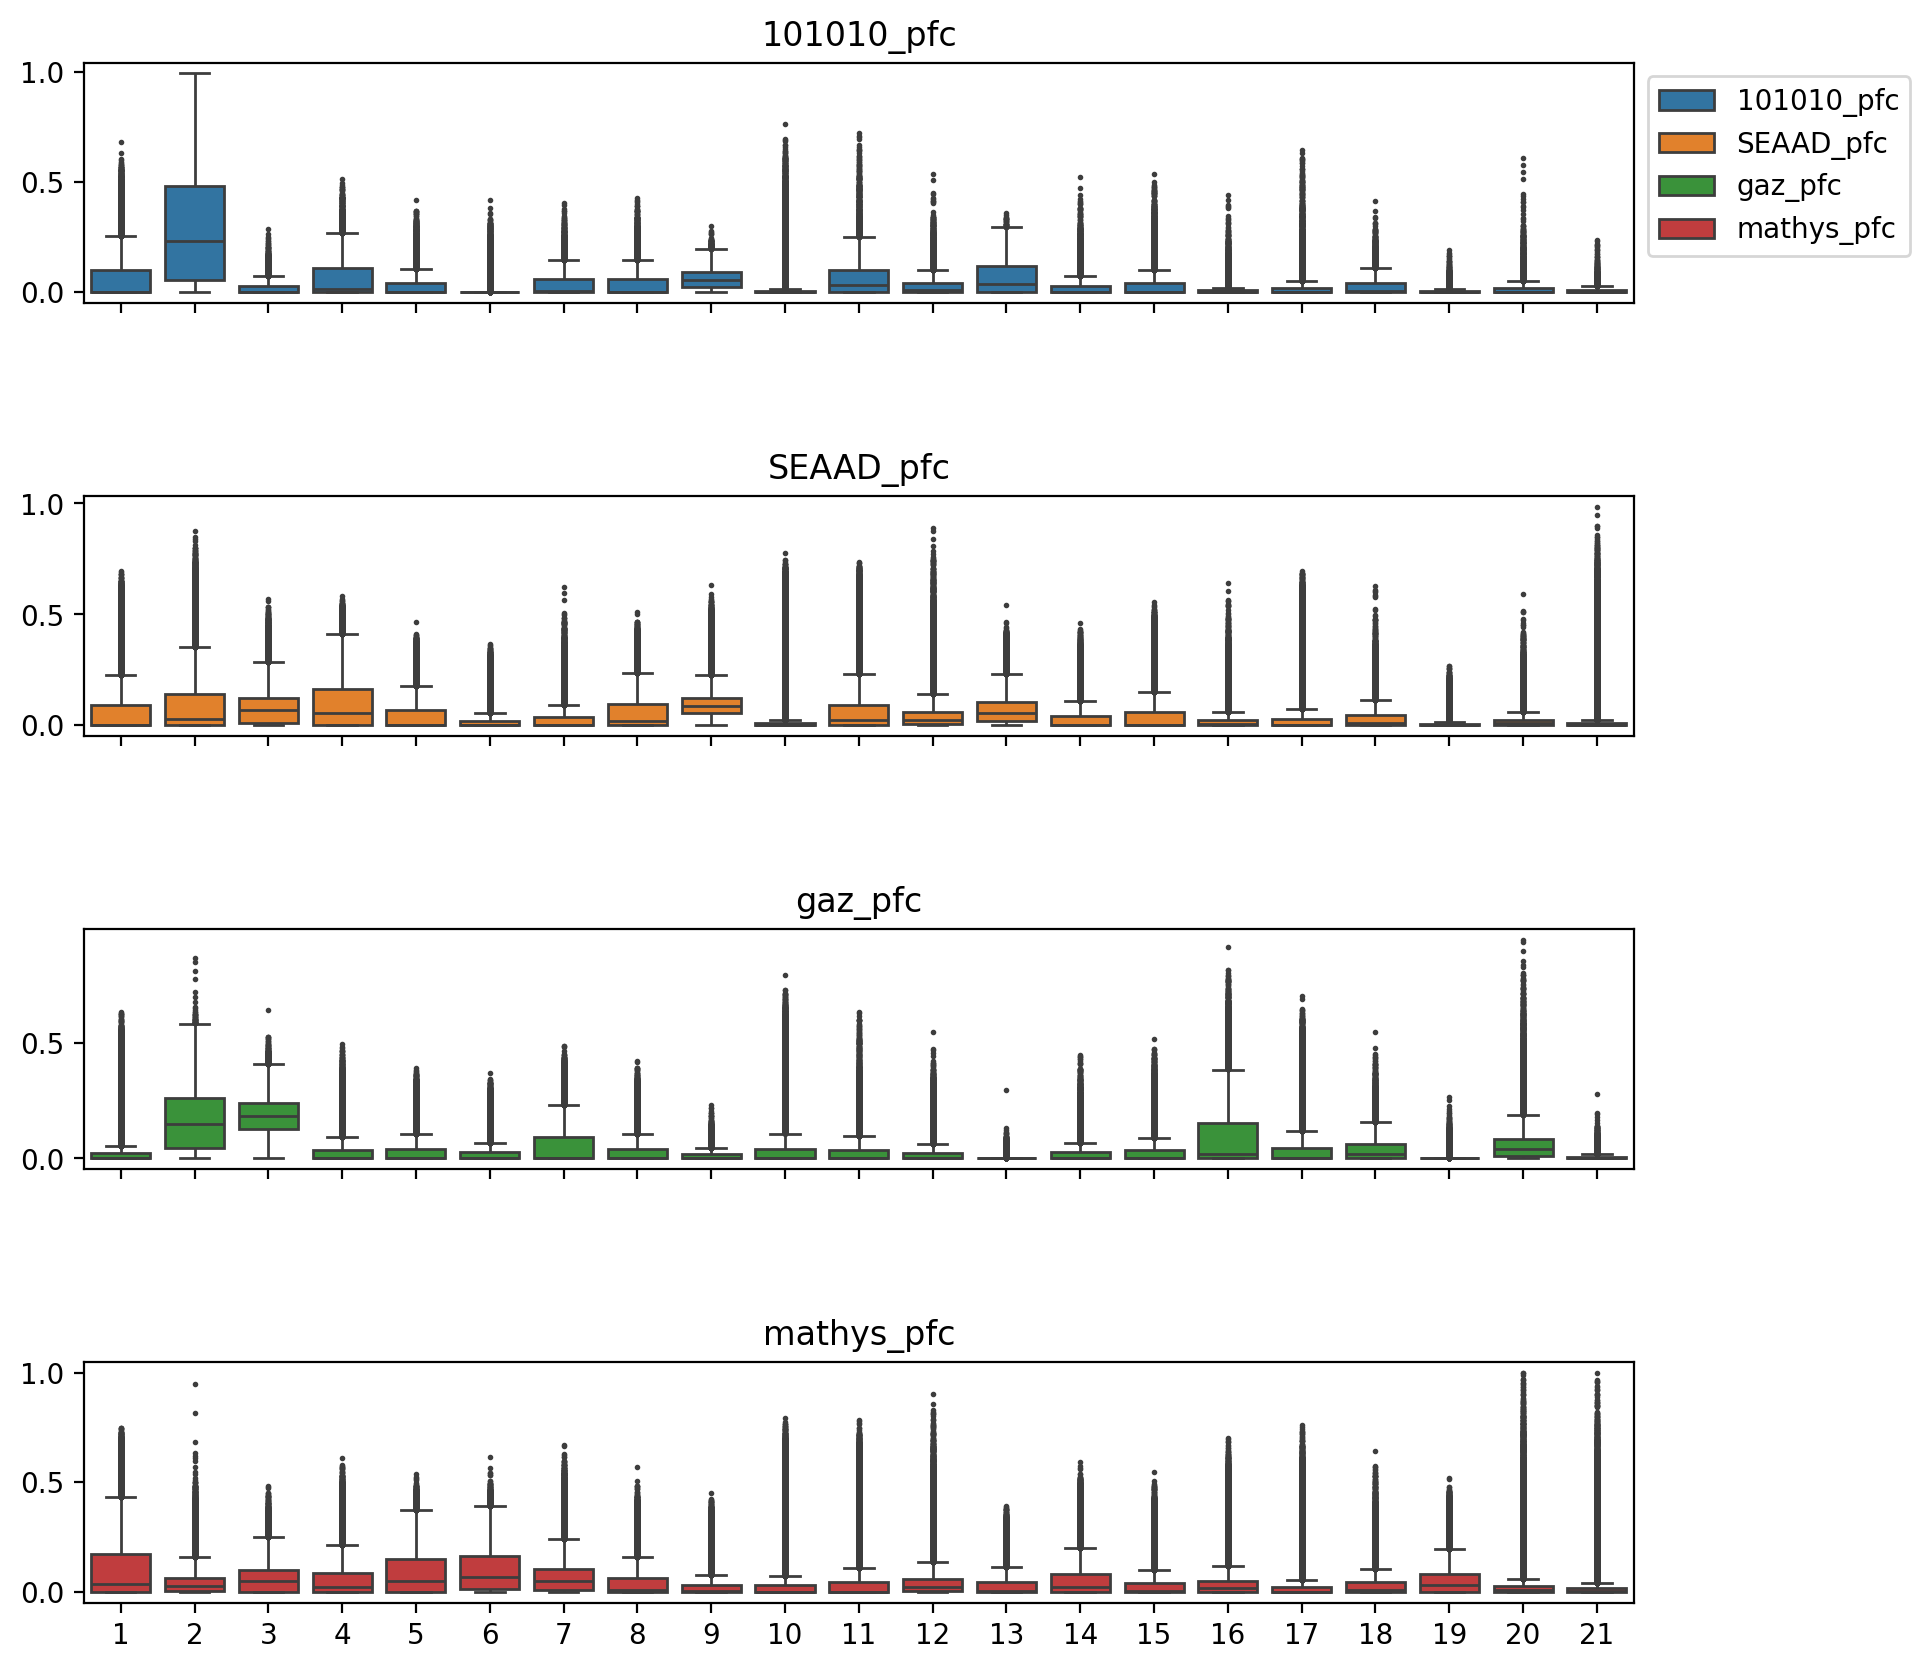

In [17]:
import seaborn as sns 

usage_norm_forplot = pd.merge(left=usage_norm_forplot, right=combined_adata.obs[['dataset',  'Donor.ID']], left_on='level_1', right_index=True)
usage_norm_forplot.columns = ['GEP', 'cell', 'Usage', 'dataset','Donor']

cluster_order = combined_adata.obs['dataset'].unique()

(fig,axes) = plt.subplots(len(cluster_order),1, figsize=(10,10), dpi=200, gridspec_kw={'hspace':.8})
for i,k in enumerate(cluster_order):
    g = usage_norm_forplot.loc[usage_norm_forplot['dataset'] == k, :]
    sns.boxplot(x='GEP', y='Usage', hue='dataset', ax=axes[i], data=g, fliersize=1)
    axes[i].set_title(k)
    axes[i].legend(bbox_to_anchor=(1,1))
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    if i != (len(cluster_order)-1):
        axes[i].set_xticklabels([])
        
    if i != 0:
        axes[i].legend().remove()
    else:
        axes[i].legend(bbox_to_anchor=(1,1))
    

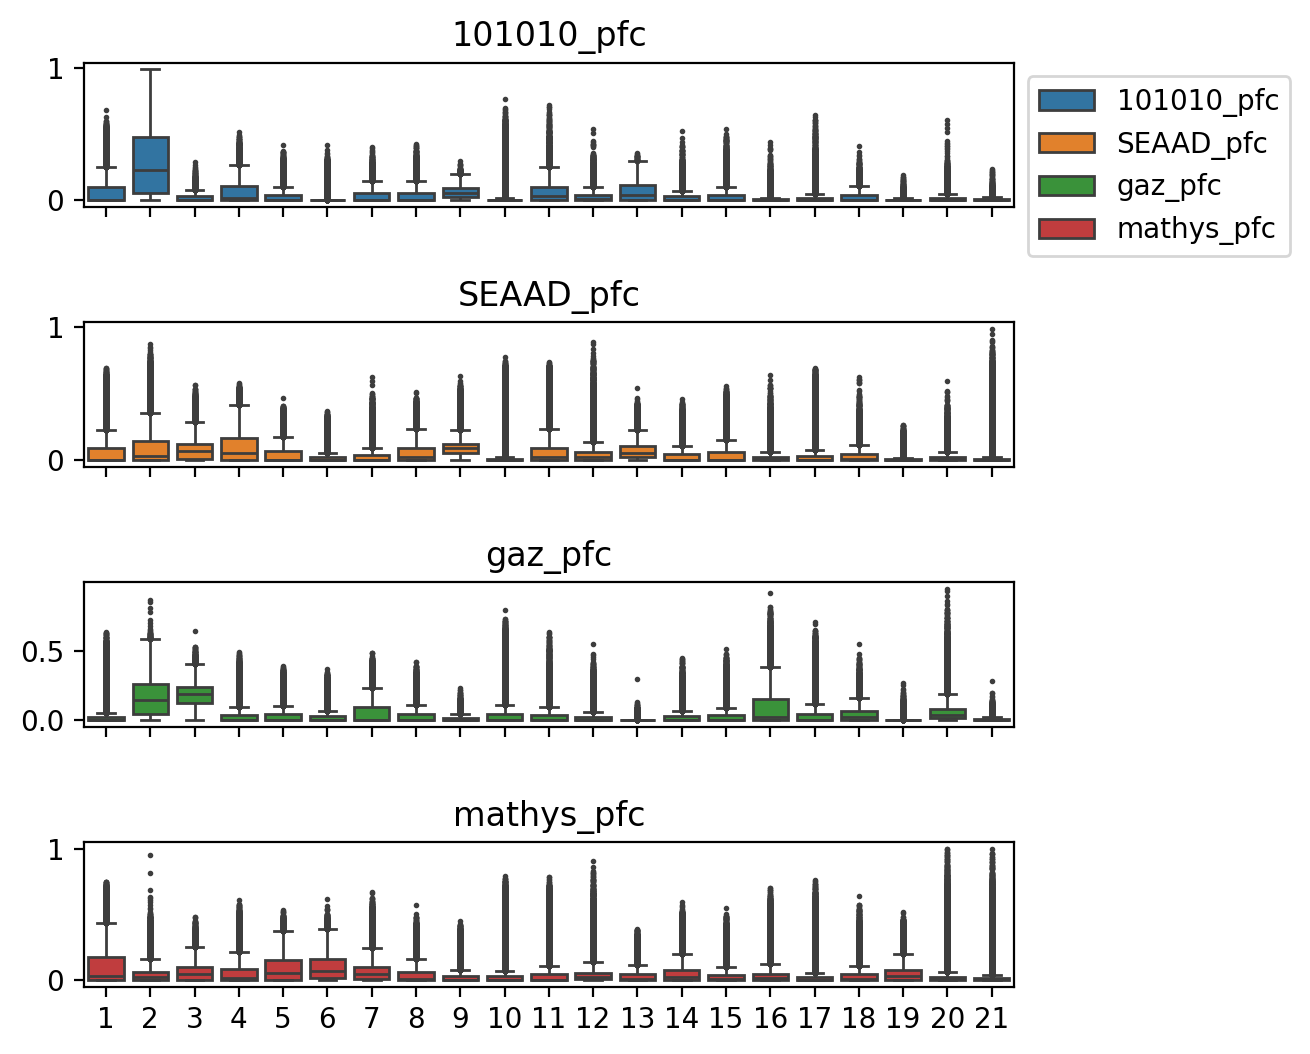

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

usage_norm_forplot = pd.merge(
    left=usage_norm_forplot,
    right=combined_adata.obs[['dataset', 'Donor.ID']],
    left_on='level_1',
    right_index=True
)
usage_norm_forplot.columns = ['GEP', 'cell', 'Usage', 'dataset', 'Donor']

cluster_order = combined_adata.obs['dataset'].unique()

fig, axes = plt.subplots(
    len(cluster_order),
    1,
    figsize=(6, 6),
    dpi=200,
    gridspec_kw={'hspace': 0.8}
)

for i, k in enumerate(cluster_order):
    g = usage_norm_forplot.loc[usage_norm_forplot['dataset'] == k, :]
    sns.boxplot(
        x='GEP',
        y='Usage',
        hue='dataset',
        ax=axes[i],
        data=g,
        fliersize=1,
        flierprops=dict(
            marker='o',
            markersize=1,
            rasterized=True
        )
    )

    axes[i].set_title(k)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    if i != (len(cluster_order) - 1):
        axes[i].set_xticklabels([])

    if i != 0:
        axes[i].legend().remove()
    else:
        axes[i].legend(bbox_to_anchor=(1, 1))

# Save BEFORE show
plt.savefig(
    "gep_usage_by_dataset_boxplots.pdf",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


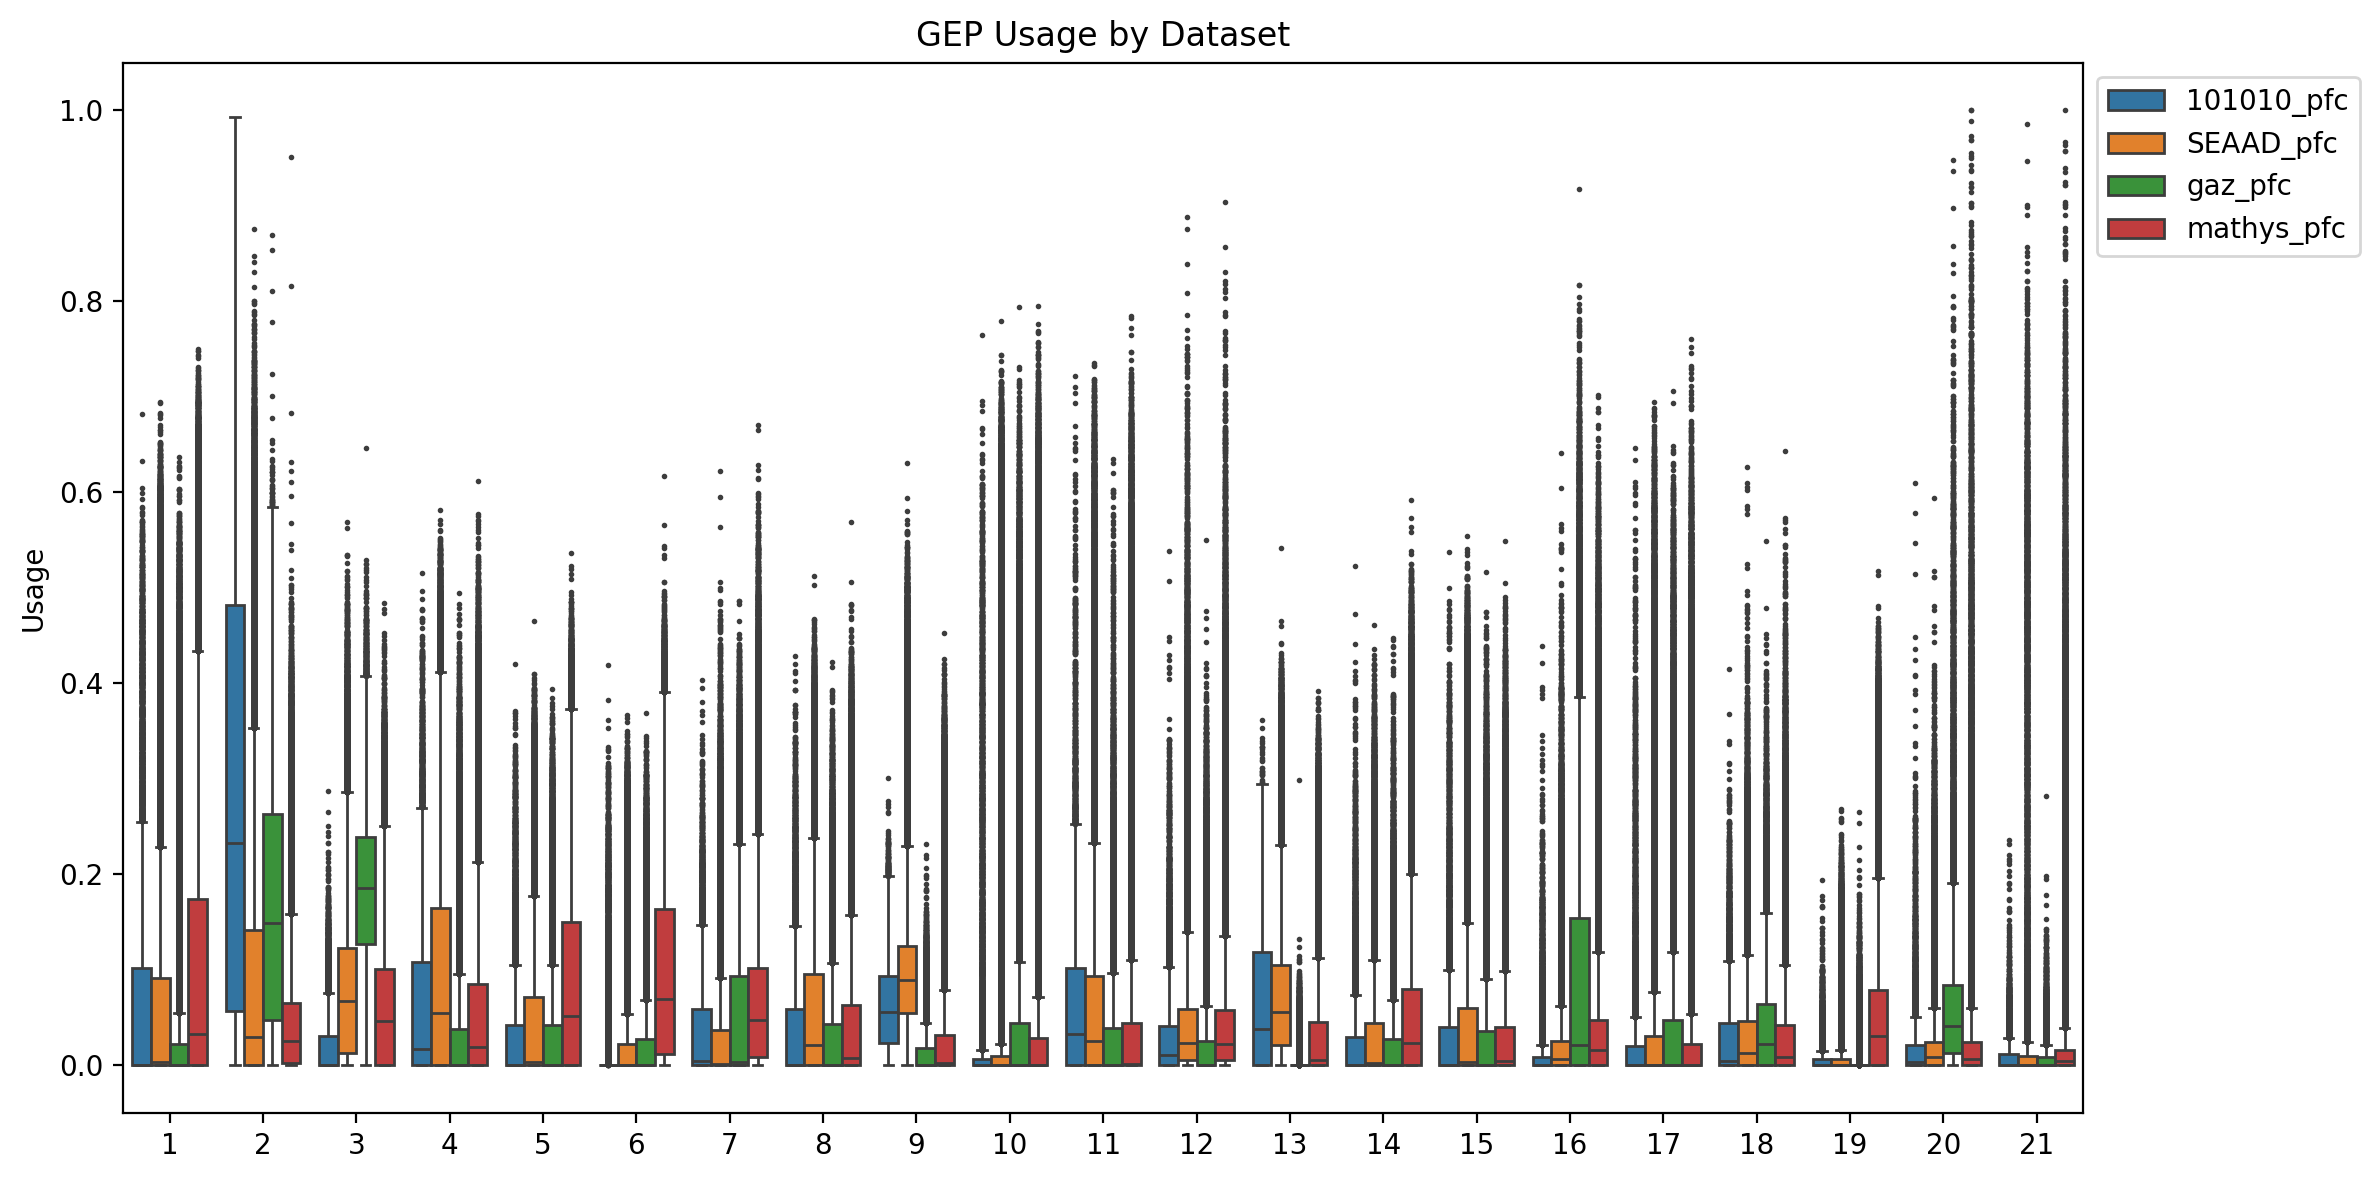

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure correct column names
usage_norm_forplot.columns = ['GEP', 'cell', 'Usage', 'dataset','Donor']

# Define dataset order if needed
cluster_order = combined_adata.obs['dataset'].unique()

# Plot
plt.figure(figsize=(12, 6), dpi=200)
sns.boxplot(x='GEP', y='Usage', hue='dataset', data=usage_norm_forplot, fliersize=1)
plt.title('GEP Usage by Dataset')
plt.xlabel('')
plt.ylabel('Usage')
plt.legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


In [19]:
top_genes_bc.to_csv('./cNMF_joint2//K21_top_genes.txt')

In [45]:
combined_adata.obs = pd.merge(left=combined_adata.obs, right=usage_bc, how='left', left_index=True, right_index=True)


In [30]:
#object with raw counts 
combined_adata_raw = sc.read_h5ad('/staging//leuven/stg_00079/projects/Magda/analysis/Narwhal/100.Process/01.ExN/12.PFC_noRef_bigger/v2_combined_PFC_L23_rawCounts_h5ad_20251106_raw_cleaned.h5ad')

#object with UMAP embeddings 
combined_adata_processed2 = sc.read_h5ad('/staging//leuven/stg_00079/projects/Magda/analysis/Narwhal/100.Process/01.ExN/12.PFC_noRef_bigger/v2_combined_PFC_L23_rawCounts_h5ad_20251106_HVGs_cleaned_umap2.h5ad')


In [5]:
# usages = usages.add_prefix("GP_")
combined_adata_processed2.obs = combined_adata_processed2.obs.join(usages)
combined_adata_processed2

AnnData object with n_obs × n_vars = 865642 × 2171
    obs: 'Donor.ID', 'dataset', 'original_annotation', 'class', 'res_leiden_0.25', 'res_leiden_0.3', 'dataset_pretty', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'class_colors', 'dataset_colors', 'dataset_pretty_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'original_annotation_colors', 'pca', 'res_leiden_0.25_colors', 'res_leiden_0.3_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

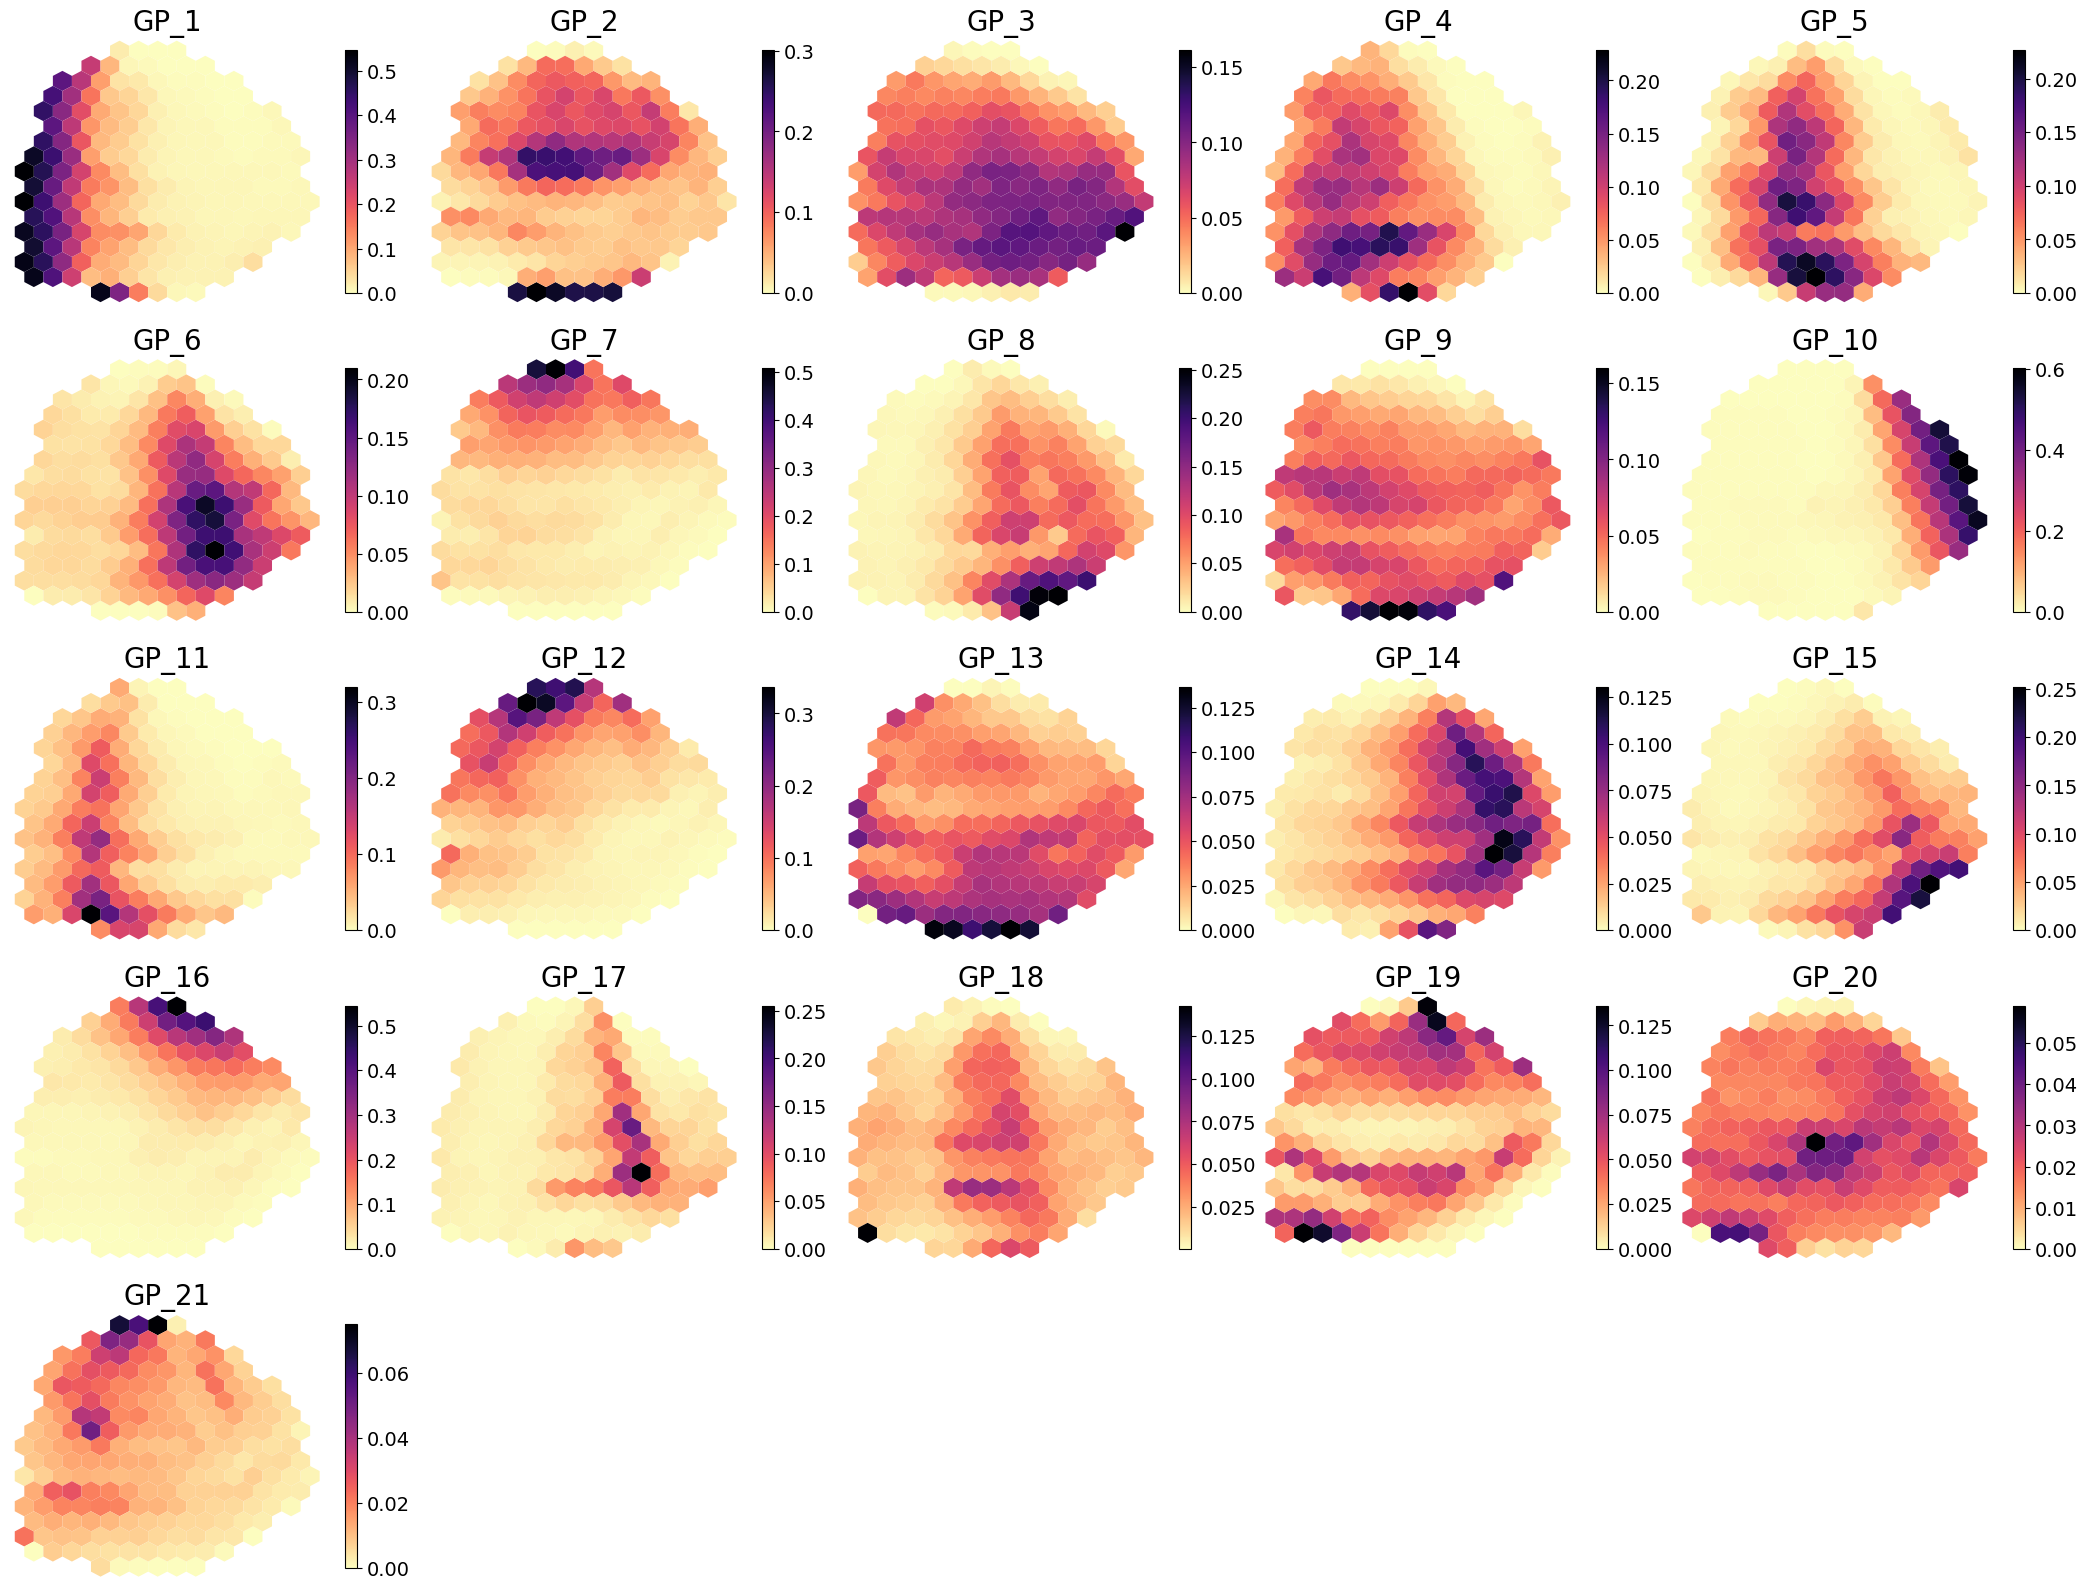

In [13]:

# extract umap coordinates
x = combined_adata_processed2.obsm['X_umap'][:, 0]
y = combined_adata_processed2.obsm['X_umap'][:, 1]

# identify gp columns
gp_columns = [col for col in combined_adata_processed2.obs.columns if col.startswith("GP")]

df = pd.DataFrame({
    'UMAP1': x,
    'UMAP2': y
})
for col in gp_columns:
    df[col] = combined_adata_processed2.obs[col].values

n_cols = 5
n_rows = int(np.ceil(len(gp_columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5.2, n_rows * 4))
axes = axes.flatten()

# # Shared color scale
# vmin = np.percentile(df[gp_columns].values, 2)
# vmax = np.percentile(df[gp_columns].values, 98)

# plot each gp columns
for i, gp in enumerate(gp_columns):
    ax = axes[i]

    hb = ax.hexbin(
        df['UMAP1'], df['UMAP2'],
        C=df[gp],
        reduce_C_function=np.mean,
        gridsize=15,
        cmap='magma_r',
        linewidths=0
    )

    # Colorbar (no title, larger ticks, more space)
    cb = fig.colorbar(hb, ax=ax, fraction=0.035, pad=0.06)  # ⬅️ increased pad from 0.02 → 0.06
    cb.ax.tick_params(labelsize=14)
    cb.set_label('', fontsize=0)

    # Aesthetics — remove all frames and ticks
    ax.set_title(gp, fontsize=20)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

# Hide unused axes
for j in range(len(gp_columns), len(axes)):
    axes[j].axis('off')

# Add spacing between plots
plt.subplots_adjust(wspace=0.2, hspace=0.2)  # ⬅️ extra spacing between panels
plt.show()


In [33]:
# for raw object, integrate UMAP coordinates 
combined_adata_raw.obsm['X_umap'] = combined_adata_processed2.obsm['X_umap'].copy()
combined_adata_raw.obs = combined_adata_raw.obs.join(usages)


In [38]:
combined_adata_raw.write_h5ad('../../../100.Process/01.ExN/12.PFC_noRef_bigger/v2_combined_PFC_L23_rawCounts_h5ad_20251106_raw_cleaned_withGPs.h5ad')


